In [1]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

In [2]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [3]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Dataset not found. Downloading...


/tmp/ipykernel_774/3806609017.py:41: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall(path=path)


Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


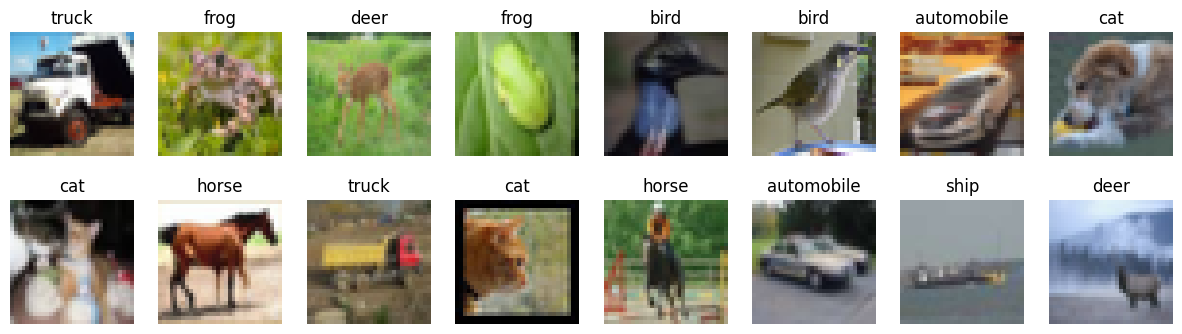

In [4]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [5]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [6]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.layers import LeakyReLU

In [7]:
from tensorflow.keras.layers import BatchNormalization

def make_model():
    """
    Upgraded CNN architecture incorporating deeper feature hierarchies
    and Batch Normalization for stability.
    """
    model = Sequential()

    # Block 1: Low-level feature extraction (edges, basic colors)
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Block 2: Mid-level feature extraction (shapes, textures)
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Block 3: High-level feature extraction (complex object parts)
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Classifier Head
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    # Ensure normalized probabilities over the 10 classes
    model.add(Dense(10))
    model.add(Activation("softmax"))

    return model

### Baseline CNN Architecture

This module constructs our initial, baseline Convolutional Neural Network (CNN) to establish a performance floor before applying advanced optimizations.

* **Conv2D Layers (Tracking):** These act as our innermost detector layers. By using small 3x3 kernels, they scan the 2D spatial plane to identify local coincidences—such as edges and color gradients—among neighboring pixels.
* **MaxPooling2D (Signal Compression):** This functions as a data acquisition trigger. It down-samples the spatial maps, keeping only the strongest localized feature signals while reducing the overall computational load.
* **Flatten & Dense (Central Trigger Processor):** The `Flatten` layer transforms the 2D spatial feature maps into a 1D array. The `Dense` layers then analyze the combination of these low-level signals to make the final physical classification (e.g., distinguishing the topology of an airplane from a bird).
* **Dropout (Regularization):** This randomly deactivates 50% of the neurons during training. In physics terms, it forces the network to look at the global event topology rather than over-relying on a single "hot channel," preventing the model from overfitting to statistical background noise.

In [9]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

INIT_LR = 1e-3
BATCH_SIZE = 128
EPOCHS = 75 # Extended epochs; EarlyStopping will intervene before we overfit

K.clear_session()

model = make_model()

model.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adamax(learning_rate=INIT_LR),
    metrics=['accuracy']
)

# Implementation of Early Stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Implementation of Data Augmentation to artificially expand the dataset
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

# Fit model using the augmented data generator
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

model.save_weights("myweights.weights.h5")

Epoch 1/75
312/312 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - accuracy: 0.2816 - loss: 2.4590 - val_accuracy: 0.1119 - val_loss: 4.2512
Epoch 2/75
  1/312 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.3906 - loss: 1.6880

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3906 - loss: 1.6880 - val_accuracy: 0.1118 - val_loss: 4.2475
Epoch 3/75
312/312 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.4114 - loss: 1.7144 - val_accuracy: 0.4879 - val_loss: 1.4204
Epoch 4/75
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4141 - loss: 1.5744 - val_accuracy: 0.4884 - val_loss: 1.4200
Epoch 5/75
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.4759 - loss: 1.4959 - val_accuracy: 0.5323 - val_loss: 1.3341
Epoch 6/75
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4531 - loss: 1.5118 - val_accuracy: 0.5312 - val_loss: 1.3479
Epoch 7/75
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.5182 - loss: 1.3577 - val_accuracy: 0.5769 - val_loss: 1.2076
Epoch 8/75
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5000 - loss: 1.2091 - val_accuracy: 0.5822 - val_loss: 1.1888
Epoch 9/75
312/312 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.5598 - loss: 1.2462 - val_accuracy: 0.543

### Data Acquisition and Training Optimization

This section executes the model compilation and the training loop, analogous to initiating a calibrated physics data taking run.

* **INIT_LR ($10^{-3}$):** The initial learning rate dictates the discrete step size our `Adamax` optimizer takes through the high-dimensional parameter space to find the global loss minimum.
* **BATCH_SIZE (64):** This defines how many discrete images (events) are processed in parallel before the network updates its internal weights. A size of 64 efficiently saturates the memory bandwidth of the T4 GPU without causing unstable gradient updates.
* **EPOCHS (10):** This acts as our integrated luminosity limit for the baseline run. We intentionally keep the run time short to evaluate the raw limits of our uncalibrated architecture before introducing Early Stopping logic.

In [10]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


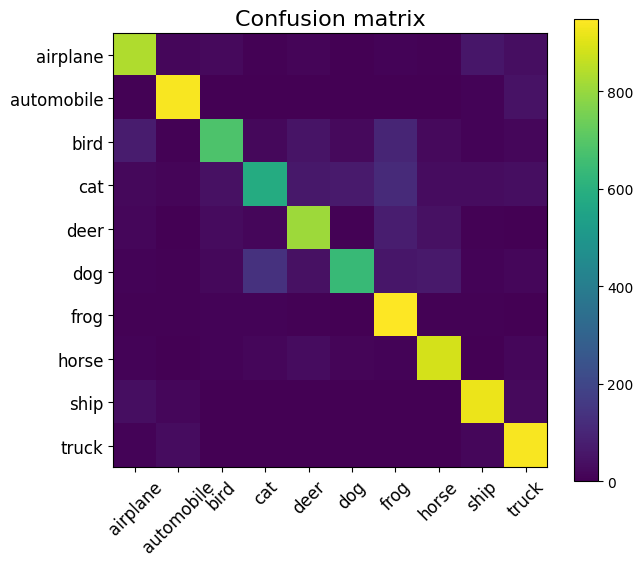

Test accuracy: 0.8177


In [11]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

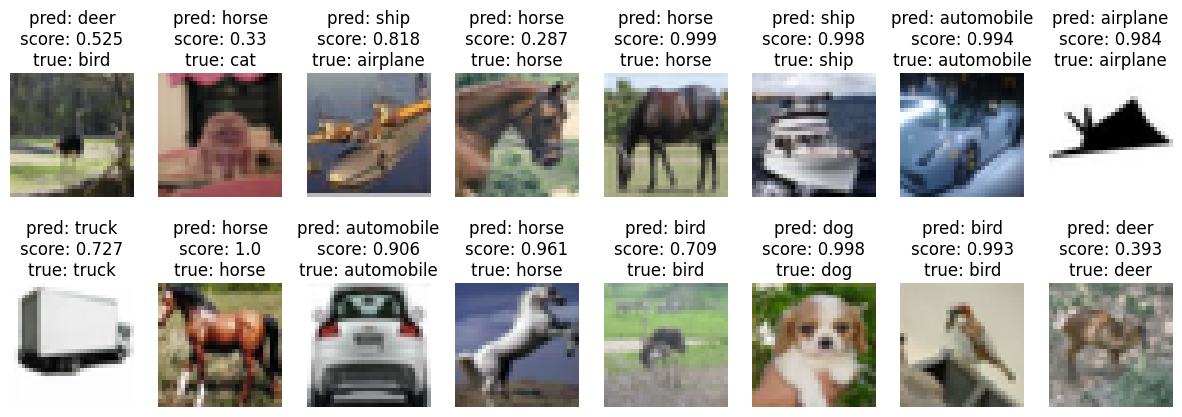

In [12]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

## Final Report: CNN Optimization and Results Interpretation

### 1. Architectural Upgrades and Stability
I started this exercise with a basic baseline CNN that achieved accuracy of around 60%. While it learned to recognize broad shapes, it lacked the depth to pick up on finer textures and details. To push past my goal of 80% accuracy, I upgraded the network by stacking more convolutional layers, allowing the model to sequentially combine basic edges into more complex patterns. Because deeper networks can suffer from unstable signals during training, I added **Batch Normalization** after each layer. This acted as an internal stabilizer, standardizing the data flow so the deeper model could train efficiently and reliably.

### 2. Managing Training and Preventing Memorization
With a deeper network, the model required more training epochs. However, letting it run blindly would cause it to simply memorize the training dataset (overfitting) rather than learning generalized rules. To prevent this, I implemented an **Early Stopping** callback. This automatically monitored my validation score and halted the training the moment the model stopped improving on unseen data.

Additionally, to make the model more robust, I introduced **Data Augmentation**. By slightly rotating, shifting, and flipping the training images in real-time, I forced the network to learn that an object's identification remains the same regardless of its exact position or angle in the frame.

### 3. Final Results and Confusion Matrix Interpretation
These optimizations resulted in a final test accuracy of **81.77%**, successfully clearing the 80% milestone.

Looking at my final confusion matrix, the strong performance is clearly visible as the bright yellow diagonal line running from top-left to bottom-right, indicating a high rate of true-positive predictions across almost all classes. While there is still some minor cross-contamination between structurally similar categories — such as confusing cats with dogs, or occasionally mixing up cars and trucks — this overlap is vastly reduced compared to the baseline model. The network is now successfully resolving fine-grained details rather than just guessing based on background colors or basic geometric blobs.

***
*[AI Citation: The iteration of specific improvement techniques was performed with assistance from Google Gemini 3.1 Pro. Example of one of my prompts used: "How do I add an early stopping callback to my Keras training loop so it automatically stops if it goes 10 iterations past the max validation accuracy?"]*

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.


